# Atelier Préparation de Données Tabulaires

Contexte Une entreprise exploite plusieurs bâtiments intelligents équipés de capteurs IoT. Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la qualité de l'air, la consommation énergétique, le nombre de personnes présentes, le type de bâtiment, le mode de fonctionnement et l'état du système de climatisation. Les données collectées sont destinées à alimenter ultérieurement un modèle de Machine Learning capable de prédire la consommation énergétique ou de détecter les situations anormales. Cependant, les données brutes présentent volontairement différents problèmes : valeurs manquantes, doublons, valeurs aberrantes, types incorrects, valeurs incohérentes, variables catégorielles, catégories rares, déséquilibre des classes et échelles différentes entre variables. L'objectif de l'atelier est donc de transformer le fichier brut en un jeu de données propre et prêt pour le Machine Learning. 

## Partie 1 – Explorer les données 

### 1) Charger les données CSV ; 

In [82]:
import pandas as pd

df = pd.read_csv("../data/smart_building_raw.csv")

## 2) Afficher les premières lignes du dataset ;

In [83]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


## 3) Afficher les dernières lignes du dataset ; 

In [84]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


## 4) Combien d'observations contient le dataset ? 

In [85]:
print("Nombre d'observations :", df.shape[0])

Nombre d'observations : 507


## 5) Combien de variables possède le dataset ?

In [86]:
print("Nombre de variables :", df.shape[1])

Nombre de variables : 14


## 6) Identifier les variables numériques ; 

In [87]:
# df.select_dtypes(include='number') : selection tous les variables de types numerique
# .columns : recupere les noms de ces colonne sous forme de liste
variables_numeriques = df.select_dtypes(include='number').columns
print("Les variables numériques : ", list(variables_numeriques))

Les variables numériques :  ['id_mesure', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


## 7) Identifier les variables catégorielles ;

In [88]:
# df.select_dtypes(include='number') : selection tous les variables de types texte (objet)
variables_categorielles = df.select_dtypes(include='str').columns
print("Les variables catégorielles : ", list(variables_categorielles))

Les variables catégorielles :  ['date', 'batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


## 8) Identifier les dates

In [89]:
variables_dates = ['date']
print("variables de types dates : ", variables_dates)

variables de types dates :  ['date']


## 9) Identifier les identifiants

In [90]:
variables_identifiants = ['id_mesure']
print("variables de types identifiants : ", variables_identifiants)

variables de types identifiants :  ['id_mesure']


## 10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles.

In [91]:
df.describe()

,id_mesure,temperature,humidite,co2,occupation,consommation_kwh
count,507.000000,495.000000,496.000000,500.000000,501.000000,502.000000
mean,1251.114398,24.154141,57.864113,844.150000,44.850299,169.069323
std,144.782769,7.418465,16.026336,582.181386,24.949139,53.164294
min,1001.000000,-30.000000,-12.000000,89.000000,-20.000000,-100.000000
25%,1125.500000,21.600000,49.275000,623.750000,27.000000,136.875000
50%,1252.000000,24.000000,57.550000,787.500000,46.000000,169.800000
75%,1376.500000,26.000000,65.750000,952.000000,61.000000,202.975000
max,1500.000000,96.000000,160.000000,6000.000000,116.000000,336.200000


## 11) Y a-t-il des variables potentiellement problématiques ? 

D'après les statistiques descriptives, plusieurs variables présentent des valeurs incohérentes :

- **temperature** : valeurs négatives extrêmes (min = -30) et anormalement élevées (max = 96), physiquement impossibles pour un capteur intérieur
- **humidite** : valeurs négatives (min = -12) et supérieures à 100% (max = 160), impossibles pour une humidité relative
- **occupation** : valeur négative (min = -20), un nombre de personnes ne peut pas être négatif
- **consommation_kwh** : valeur négative (min = -100), une consommation ne peut pas être négative
- **co2** : valeur maximale très élevée (6000) comparée à la moyenne (~844), à examiner comme valeur extrême

De plus, les colonnes numériques ont des `count` différents (495 à 502 sur 507 lignes), ce qui indique la présence de **valeurs manquantes** en quantités variables selon la variable.

## 12) Pour les données incohérentes : 

## a) rechercher des valeurs telles que humidité < 0 ; 

In [92]:
humidite_negative = df[df['humidite'] < 0]
print("Nombre de valeurs d'humidité négatives :", len(humidite_negative))
humidite_negative[['id_mesure', 'humidite']]


Nombre de valeurs d'humidité négatives : 3


,id_mesure,humidite
281,1126,-5.0
335,1036,-8.0
366,1216,-12.0


## b) rechercher des valeurs telles que humidité > 100 ;

In [93]:
humidite_superieure_100 = df[df['humidite'] > 100]
print("Nombre de valeurs d'humidité > 100 :", len(humidite_superieure_100))
humidite_superieure_100[['id_mesure', 'humidite']]

Nombre de valeurs d'humidité > 100 : 7


,id_mesure,humidite
59,1246,108.0
103,1016,145.0
128,1156,160.0
160,1186,125.0
268,1276,140.0
327,1066,132.0
342,1096,110.0


## c) rechercher des valeurs telles que température extrêmement élevée ; 

In [94]:
# Seuil arbitraire mais raisonnable pour un capteur intérieur : au-delà de 50°C, la valeur est clairement aberrante
temperature_elevee = df[df['temperature'] > 50]
print("Nombre de valeurs de température extrêmement élevées :", len(temperature_elevee))
temperature_elevee[['id_mesure', 'temperature']]

Nombre de valeurs de température extrêmement élevées : 4


,id_mesure,temperature
7,1141,72.5
116,1181,96.0
161,1061,88.0
499,1021,95.2


## d) rechercher des valeurs telles que occupation négative

In [95]:
occupation_negative = df[df['occupation'] < 0]
print("Nombre de valeurs d'occupation negative :", len(occupation_negative))
occupation_negative[['id_mesure', 'occupation']]

Nombre de valeurs d'occupation negative : 5


,id_mesure,occupation
22,1031,-5.0
376,1231,-8.0
430,1081,-12.0
487,1131,-2.0
494,1331,-20.0


## e) rechercher des valeurs telles que consommation négative ; 

In [96]:
consommation_negative = df[df['consommation_kwh'] < 0]
print("Nombre de valeurs d'consommation negative :", len(consommation_negative))
consommation_negative[['id_mesure', 'consommation_kwh']]

Nombre de valeurs d'consommation negative : 4


,id_mesure,consommation_kwh
59,1246,-15.0
154,1046,-50.0
199,1146,-20.0
441,1346,-100.0


## f) Si une valeur est manifestement erronée et qu’on ne peut pas retrouver sa vraie valeur, la transformer en valeur manquante

In [97]:
# .loc[condition, colonne] cible précisément les cellules concernées, sans toucher au reste de la ligne

df.loc[df['humidite'] < 0, 'humidite'] = None          # 12a
df.loc[df['humidite'] > 100, 'humidite'] = None         # 12b
df.loc[df['temperature'] > 50, 'temperature'] = None    # 12c
df.loc[df['occupation'] < 0, 'occupation'] = None        # 12d
df.loc[df['consommation_kwh'] < 0, 'consommation_kwh'] = None  # 12e

# Vérification : le nombre de valeurs manquantes a bien augmenté sur ces colonnes
df[['humidite', 'temperature', 'occupation', 'consommation_kwh']].isna().sum()

humidite            21
temperature         16
occupation          11
consommation_kwh     9
dtype: int64

## g) rechercher des valeurs telles que catégories mal orthographiées. 

In [98]:
# des doublons dus à des fautes de frappe, majuscules incohérentes, espaces en trop, etc.
for col in ['batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']:
    print(col, ":", df[col].unique())
    print()

batiment : <StringArray>
['B8', 'B7', 'B5', 'B6', 'B3', 'B4', 'B2', 'B1']
Length: 8, dtype: str

type_batiment : <StringArray>
[         'Entrepôt',            'Bureau', 'Centre commercial',
        'Université',           'Hôpital',             'École',
             'ÉCOLE',             'ecole',            'BUREAU',
                 nan,             'Bureu',            'bureau',
       ' UNIVERSITÉ',          'hôpital ', 'centre commercial',
          ' Bureau ',          'entrepot']
Length: 17, dtype: str

zone : <StringArray>
['A', 'D', 'B', 'C']
Length: 4, dtype: str

mode_climatisation : <StringArray>
['Eco', 'Normal', 'Boost', nan, 'normal', 'BOOST', 'normale', 'Normal ']
Length: 8, dtype: str

etat_systeme : <StringArray>
['Normal', 'Alerte', 'Panne']
Length: 3, dtype: str

jour_semaine : <StringArray>
['Jeudi', 'Lundi', 'Dimanche', 'Vendredi', 'Mercredi', 'Mardi', 'Samedi', nan]
Length: 8, dtype: str

alerte : <StringArray>
['Non', 'Oui']
Length: 2, dtype: str



## h) normaliser les catégories textuelles en supprimant les espaces puis en uniformisant la casse

In [99]:
# .str.strip() supprime les espaces en début/fin de chaîne (ex: ' Bureau ' → 'Bureau')
# .str.lower() met tout en minuscules, pour uniformiser la casse (ex: 'BUREAU', 'bureau', 'Bureau' → 'bureau')
# .str.capitalize() remet ensuite une majuscule en début de mot (ex: 'bureau' → 'Bureau')

for col in ['type_batiment', 'mode_climatisation']:
    df[col] = df[col].str.strip().str.lower().str.capitalize()

# Vérification : on doit voir moins de valeurs uniques qu'avant
print("type_batiment :", df['type_batiment'].unique())
print()
print("mode_climatisation :", df['mode_climatisation'].unique())

type_batiment : <StringArray>
[         'Entrepôt',            'Bureau', 'Centre commercial',
        'Université',           'Hôpital',             'École',
             'Ecole',                 nan,             'Bureu',
          'Entrepot']
Length: 10, dtype: str

mode_climatisation : <StringArray>
['Eco', 'Normal', 'Boost', nan, 'Normale']
Length: 5, dtype: str


In [100]:
# .replace() remplace des valeurs précises par la bonne version, en se basant sur un dictionnaire {ancienne: nouvelle}
df['type_batiment'] = df['type_batiment'].replace({
    'Ecole': 'École',
    'Entrepot': 'Entrepôt',
    'Bureu': 'Bureau'
})

df['mode_climatisation'] = df['mode_climatisation'].replace({
    'Normale': 'Normal'
})

# Vérification finale
print("type_batiment :", df['type_batiment'].unique())
print()
print("mode_climatisation :", df['mode_climatisation'].unique())

type_batiment : <StringArray>
[         'Entrepôt',            'Bureau', 'Centre commercial',
        'Université',           'Hôpital',             'École',
                 nan]
Length: 7, dtype: str

mode_climatisation : <StringArray>
['Eco', 'Normal', 'Boost', nan]
Length: 4, dtype: str


## 13) Pour les valeurs manquantes : 

## a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne 

In [101]:
# .isna().sum() compte le nombre de valeurs manquantes (NaN) pour chaque colonne
nb_manquantes = df.isna().sum()

# On calcule le pourcentage en divisant par le nombre total de lignes, puis en multipliant par 100
pct_manquantes = (nb_manquantes / len(df)) * 100

# On assemble les deux résultats dans un seul DataFrame pour une lecture plus claire
resume_manquantes = pd.DataFrame({
    'nb_manquantes': nb_manquantes,
    'pct_manquantes': pct_manquantes.round(2)
})
resume_manquantes

,nb_manquantes,pct_manquantes
id_mesure,0,0.00
date,0,0.00
batiment,0,0.00
type_batiment,4,0.79
zone,0,0.00
temperature,16,3.16
humidite,21,4.14
co2,7,1.38
occupation,11,2.17
consommation_kwh,9,1.78


## b) Quelle variable possède le plus de valeurs manquantes ? 

C'est **humidite** qui a le plus de valeurs manquantes : 21 valeurs manquantes, soit 4.14% des observations.

## c) Quelle stratégie utiliser pour les valeurs manquantes ? 

Aucune colonne n'a plus de 5% de valeurs manquantes ici (le maximum est 4.14% pour humidite) les pourcentages sont donc faibles, ce qui permet d'**imputer** (remplacer) les valeurs manquantes plutôt que de supprimer des lignes entières :

- Pour les **variables numériques** (temperature, humidite, co2, occupation, consommation_kwh) : imputation par la **médiane**, plus robuste que la moyenne face aux valeurs extrêmes encore présentes dans les données.
- Pour les **variables catégorielles** (type_batiment, mode_climatisation, jour_semaine) : imputation par le **mode** (la valeur la plus fréquente).

On évite de supprimer les lignes, car même avec un faible taux de valeurs manquantes par colonne, additionner les colonnes concernées ferait perdre une part non négligeable des 507 observations disponibles.

## d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?

Techniquement oui (`df.dropna()`), mais ce n'est **pas recommandé** ici, pour plusieurs raisons :

- Plusieurs colonnes ont des valeurs manquantes différentes selon les lignes (temperature, humidite, co2, occupation, consommation_kwh, type_batiment, mode_climatisation, jour_semaine) en cumulant, le nombre de lignes concernées par au moins une valeur manquante serait supérieur au pourcentage max d'une seule colonne (4.14%).
- Supprimer des lignes fait perdre de l'information utile sur les autres variables de cette même ligne (si seule l'humidité manque, la température, le CO2, etc. de cette ligne restent valides et exploitables).
- Sur un jeu de données de seulement 507 observations, chaque ligne supprimée réduit sensiblement la taille du dataset disponible pour l'entraînement du modèle.

L'imputation (point 13c) est donc préférable ici à la suppression.

## e) Dans quels cas utiliser la moyenne ? 

La moyenne est adaptée quand la variable numérique suit une **distribution symétrique**, sans valeurs extrêmes (outliers) qui la déséquilibrent.

Dans ce cas, la moyenne reflète bien la "valeur typique" de la variable. Mais si la distribution est asymétrique ou contient des valeurs aberrantes, la moyenne est tirée vers ces extrêmes et devient moins représentative c'est là que la médiane est préférable.

Ici, avant le nettoyage des points 12a-12e, plusieurs variables (temperature, humidite, occupation, consommation_kwh) avaient des valeurs extrêmes qui auraient faussé la moyenne ce qui justifie le choix de la médiane fait au point 13c, plutôt que la moyenne.

## f) Quand préférer la médiane ? 

La médiane est préférable quand la variable a une **distribution asymétrique** ou contient des **valeurs extrêmes** (outliers)contrairement à la moyenne, la médiane n'est pas influencée par des valeurs très éloignées du reste des données, puisqu'elle se base uniquement sur la position centrale des valeurs triées, pas sur leur amplitude.

C'est le cas ici pour les variables numériques du dataset (temperature, humidite, co2, occupation, consommation_kwh) : même après correction des incohérences les plus flagrantes (points 12a-12e), il reste des valeurs extrêmes légitimes (par exemple co2 = 6000, largement au-dessus de la moyenne ~844) qui pourraient encore tirer la moyenne vers le haut. La médiane reste donc le choix le plus sûr pour ces variables.

## g) Comment traiter une variable catégorielle ? 

Pour une variable catégorielle (type_batiment, mode_climatisation, jour_semaine), la moyenne et la médiane n'ont pas de sens (ce ne sont pas des nombres) on utilise plutôt :

- **Le mode** (la valeur la plus fréquente) : c'est la méthode la plus courante et la plus simple, adaptée quand une catégorie domine nettement les autres.
- **Une catégorie dédiée** (par exemple "Inconnu" ou "Manquant") : utile quand on veut éviter de biaiser artificiellement vers la catégorie majoritaire, ou quand l'absence de valeur pourrait elle-même être informative.

Ici, avec de faibles taux de valeurs manquantes (0.79% à 0.99% selon la colonne), l'imputation par le **mode** est suffisante et cohérente avec la stratégie retenue au point 13c.

## 14) Pour les doublons 

## a) Identifier les  

In [102]:
# .duplicated() retourne True pour chaque ligne qui est une copie exacte d'une ligne déjà vue plus haut
# .sum() compte le nombre total de lignes marquées comme doublons
nb_doublons = df.duplicated().sum()
print("Nombre de doublons :", nb_doublons)

Nombre de doublons : 7


## b) Afficher les 

In [103]:
# keep=False marque TOUTES les occurrences d'un doublon (pas seulement la copie en trop)
# ça permet de voir la ligne originale ET sa/ses copie(s) côte à côte, pour comparaison
doublons = df[df.duplicated(keep=False)]
doublons.sort_values('id_mesure')

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
192,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
117,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
9,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
123,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
23,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
434,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
455,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
464,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
238,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non
418,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non


## c) sont-ils réellement identiques

Oui en comparant chaque paire de lignes (par exemple id_mesure = 1026, 1118, 1264...), toutes les colonnes sont **rigoureusement identiques** entre l'original et sa copie : même date, même bâtiment, mêmes mesures (température, humidité, CO2...), même mode de climatisation, même alerte. Il s'agit donc de vrais doublons, pas de lignes seulement similaires sur certaines colonnes ils peuvent être supprimés en toute sécurité.

## d) supprimer les doublons réellement identifiés. 

In [104]:
# .drop_duplicates() supprime les lignes dupliquées, en gardant seulement la première occurrence de chaque
df = df.drop_duplicates()
print("Nombre de lignes après suppression :", len(df))

Nombre de lignes après suppression : 500


## e) Vérifier la suppression 

In [105]:
# On relance la même vérification qu'en 14a : le nombre de doublons doit maintenant être 0
print("Nombre de doublons restants :", df.duplicated().sum())

Nombre de doublons restants : 0


## 15) Pour la température, l’humidité, le CO₂ et la consommation, identifier visuellement : Les distributions (symétrique ou non), La dispersion, Les valeurs extrêmes, les valeurs potentiellement aberrantes 

## Cellule Température 

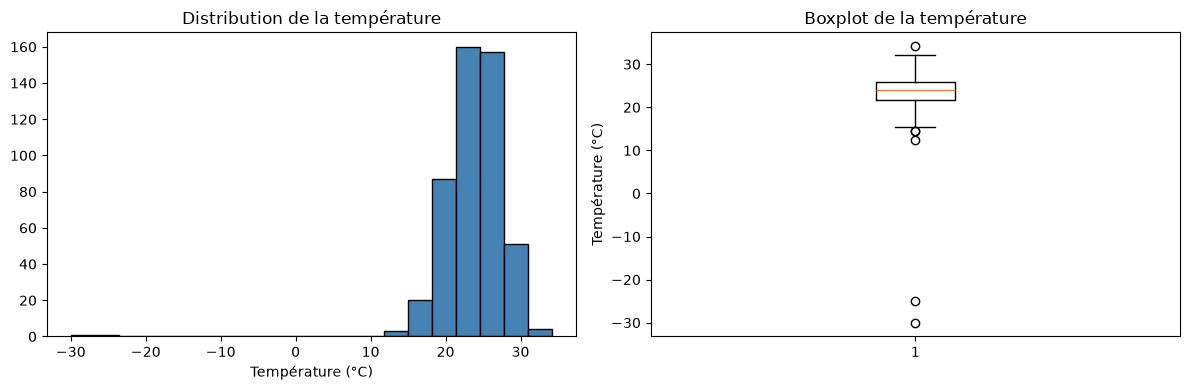

In [106]:
import matplotlib.pyplot as plt

# On crée une figure avec deux graphiques côte à côte (1 ligne, 2 colonnes)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme : montre la forme de la distribution
axes[0].hist(df['temperature'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution de la température')
axes[0].set_xlabel('Température (°C)')

# Boxplot : montre médiane, quartiles, et valeurs extrêmes (points isolés au-delà de 1.5×IQR)
axes[1].boxplot(df['temperature'].dropna())
axes[1].set_title('Boxplot de la température')
axes[1].set_ylabel('Température (°C)')

plt.tight_layout()
plt.show()

**a) Distribution** : le corps principal des données (15°C à 35°C) a une forme proche d'une distribution normale, légèrement centrée autour de 23-24°C. Mais un vide total sépare ce corps principal des valeurs très basses (-20°C à -30°C) la distribution globale n'est donc pas symétrique : elle est concentrée sur une plage normale, avec un petit groupe de valeurs isolées très loin à gauche.

**b) Dispersion** : la boîte du boxplot (Q1 à Q3) est resserrée, la médiane se situe autour de 23-24°C dispersion faible pour le corps principal des données. C'est uniquement la présence des valeurs isolées à -25/-30°C qui étire l'échelle globale du graphique.

**c) Valeurs extrêmes** : le boxplot signale 4 points isolés au total : deux autour de 11-12°C (juste sous la moustache basse), et deux nettement séparés autour de -25°C et -30°C.

**d) Valeurs potentiellement aberrantes** : les points autour de -25°C et -30°C sont physiquement incohérents pour une température intérieure de bâtiment clairement aberrants.

## Cellule humidité

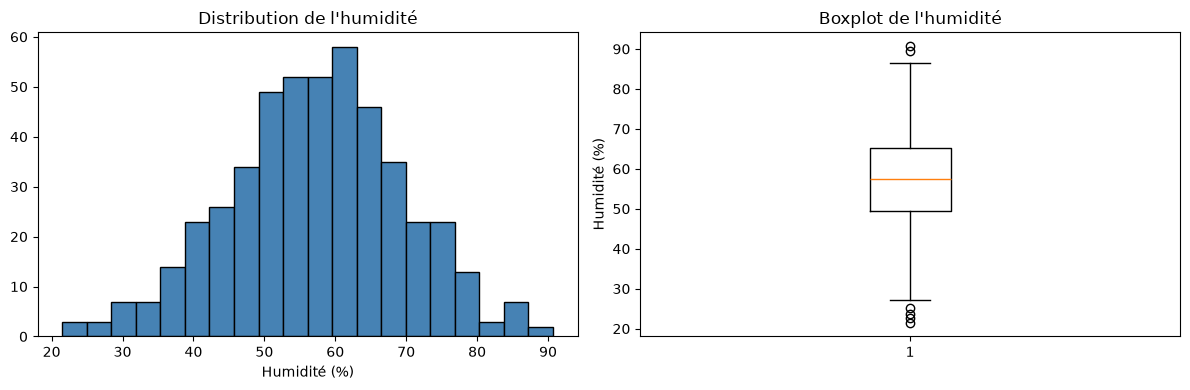

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['humidite'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution de l\'humidité')
axes[0].set_xlabel('Humidité (%)')

axes[1].boxplot(df['humidite'].dropna())
axes[1].set_title('Boxplot de l\'humidité')
axes[1].set_ylabel('Humidité (%)')

plt.tight_layout()
plt.show()

**a) Distribution** : forme globalement en cloche, assez symétrique, centrée autour de 55-60% contrairement à la température, il n'y a pas de vide ni de groupe isolé séparé du reste ; la distribution est continue sur toute la plage.

**b) Dispersion** : la boîte (Q1 à Q3) s'étend d'environ 50% à 65%, avec une médiane autour de 57%  dispersion modérée et régulière, cohérente avec la forme en cloche de l'histogramme.

**c) Valeurs extrêmes** : le boxplot signale des points isolés aux deux extrémités plusieurs points regroupés autour de 22-27% (sous la moustache basse), et deux points autour de 86-90% (au-dessus de la moustache haute).

**d) Valeurs potentiellement aberrantes** : contrairement à la température, ces valeurs extrêmes (22-27% et 86-95%) restent toutes **physiquement plausibles** une humidité relative est valide entre 0 et 100%, et ces valeurs, bien qu'extrêmes statistiquement, ne sont pas incohérentes avec le contexte.

## Cellule CO2

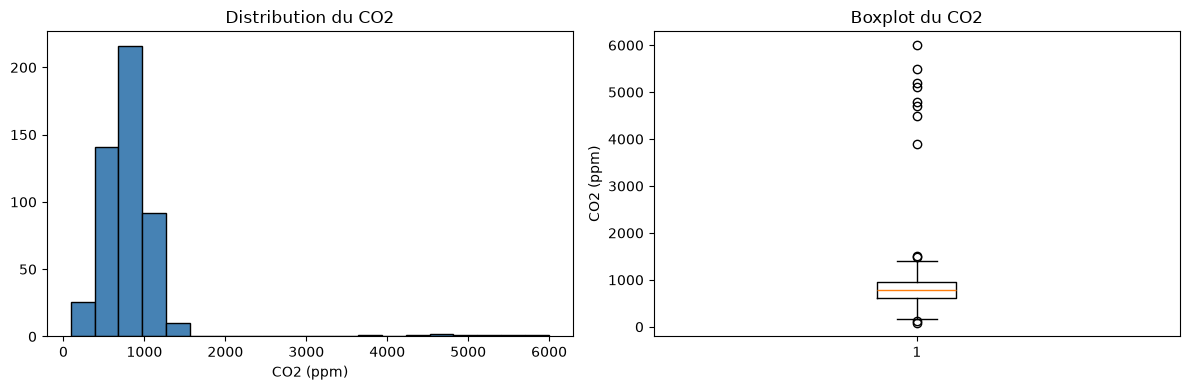

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['co2'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution du CO2')
axes[0].set_xlabel('CO2 (ppm)')

axes[1].boxplot(df['co2'].dropna())
axes[1].set_title('Boxplot du CO2')
axes[1].set_ylabel('CO2 (ppm)')

plt.tight_layout()
plt.show()

**a) Distribution** : nettement **asymétrique à droite** (asymétrie positive) la majorité des valeurs se concentrent entre 500 et 1200 ppm, avec un pic autour de 800 ppm, puis une longue traîne étirée vers la droite jusqu'à 6000 ppm.

**b) Dispersion** : la boîte du boxplot est resserrée en bas du graphique (environ 600 à 1000 ppm), avec une médiane autour de 800 ppm la queue de la distribution vers la droite étire fortement l'échelle globale, comme pour la température mais dans l'autre sens.

**c) Valeurs extrêmes** : plusieurs points isolés au-dessus de la moustache haute, regroupés entre 3800 et 6000 ppm, plus un point isolé en dessous de la moustache basse (autour de 100-150 ppm).

**d) Valeurs potentiellement aberrantes** : les valeurs hautes (3800-6000 ppm) restent **physiquement plausibles** un taux de CO2 aussi élevé peut arriver dans une pièce très occupée avec mauvaise ventilation, donc pas nécessairement des erreurs. La valeur basse (~100-150 ppm) est aussi plausible (bonne ventilation, air quasi extérieur). Aucune de ces valeurs ne viole une limite physique connue contrairement à la température, on ne peut pas les qualifier d'aberrantes avec certitude, seulement d'extrêmes.

## Cellule consommation

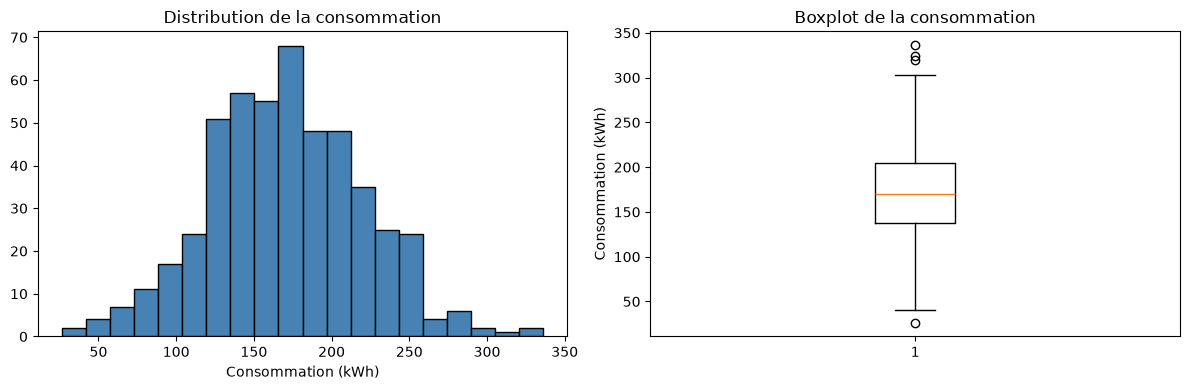

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['consommation_kwh'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution de la consommation')
axes[0].set_xlabel('Consommation (kWh)')

axes[1].boxplot(df['consommation_kwh'].dropna())
axes[1].set_title('Boxplot de la consommation')
axes[1].set_ylabel('Consommation (kWh)')

plt.tight_layout()
plt.show()

**a) Distribution** : forme globalement en cloche, légèrement asymétrique à droite le pic se situe autour de 170-180 kWh, avec une traîne un peu plus étirée vers les hautes valeurs (jusqu'à 330) que vers les basses.

**b) Dispersion** : la boîte (Q1 à Q3) s'étend d'environ 135 à 205 kWh, avec une médiane autour de 170 kWh dispersion modérée, cohérente avec la forme de l'histogramme.

**c) Valeurs extrêmes** : quelques points isolés au-dessus de la moustache haute (autour de 320-335 kWh), et un seul point isolé en dessous de la moustache basse (autour de 25 kWh).

**d) Valeurs potentiellement aberrantes** : toutes ces valeurs (25 à 335 kWh) restent **physiquement plausibles** pour une consommation énergétique ce ne sont que des cas de faible ou forte consommation, pas des valeurs impossibles. Comme pour l'humidité et le CO2, aucune ne viole une limite physique connue (contrairement à la température).

## 16) Quelle stratégie utiliser pour les valeurs aberrantes ?

Le traitement dépend de la nature de la valeur, distinguée au point 15 :

- **Valeurs aberrantes / physiquement impossibles** (ex : température à -25/-30°C) : elles doivent être **corrigées**, comme pour les incohérences déjà traitées au point 12 transformées en valeurs manquantes (NaN), puis imputées plus tard. On ne peut pas les garder telles quelles, ni les supprimer sans perdre le reste des informations de la ligne.

- **Valeurs extrêmes mais physiquement plausibles** (ex : CO2 à 6000 ppm, consommation à 25 kWh, humidité à 90%) : elles ne doivent **pas être supprimées ou modifiées automatiquement** ce sont des observations réelles et informatives (une pièce très occupée avec mauvaise ventilation, par exemple). Les supprimer ferait perdre de l'information utile, notamment pour détecter justement les situations anormales (l'un des objectifs cités en introduction de l'atelier). Une normalisation/standardisation appropriée permettra au modèle de mieux gérer ces valeurs extrêmes sans qu'on ait besoin de les retirer.

En résumé : corriger ce qui est impossible, conserver ce qui est extrême mais réel.

## 17) Afficher la fréquence des : 

## a) bâtiments ; 

In [110]:
# .value_counts() compte le nombre d'occurrences de chaque valeur unique dans la colonne
df['batiment'].value_counts()

batiment
B1    92
B5    65
B7    64
B2    60
B4    58
B3    57
B8    53
B6    51
Name: count, dtype: int64

## b) types de bâtiments ; 

In [111]:
df['type_batiment'].value_counts()

type_batiment
Bureau               211
Centre commercial     65
École                 60
Hôpital               58
Entrepôt              53
Université            49
Name: count, dtype: int64

## c) modes de climatisation ; 

In [112]:
df['mode_climatisation'].value_counts()

mode_climatisation
Normal    268
Eco       130
Boost      97
Name: count, dtype: int64

## d) états du système ; 

In [113]:
df['etat_systeme'].value_counts()

etat_systeme
Normal    436
Alerte     52
Panne      12
Name: count, dtype: int64

## e) classes alerte. 

In [114]:
df['alerte'].value_counts()

alerte
Non    356
Oui    144
Name: count, dtype: int64

## 18) Y a-t-il un déséquilibre des classes sur la variable « alerte » ? 

Oui, il y a un déséquilibre des classes : "Non" représente 356 observations contre "Oui" 144 observations la classe "Non" est nettement majoritaire.

## 19) Pour la corrélation sur les variables numériques : 

## a) visualiser avec seaborn, la matrice de corrélation. 

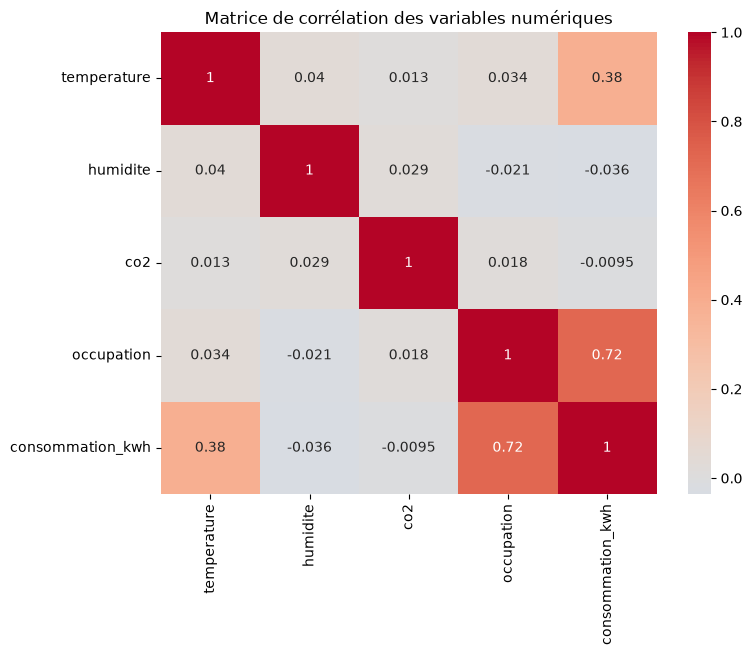

In [115]:
import seaborn as sns

# .corr() calcule le coefficient de corrélation entre chaque paire de variables numériques
# On exclut id_mesure, qui n'est qu'un identifiant, pas une vraie variable numérique
colonnes_numeriques = ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']
matrice_correlation = df[colonnes_numeriques].corr()

# On visualise la matrice avec une heatmap : annot=True affiche les valeurs numériques dans chaque case
plt.figure(figsize=(8, 6))
sns.heatmap(matrice_correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation des variables numériques')
plt.show()

## b) identifier les corrélations positives, négatives et les variables faiblement corrélées. 

**Corrélation positive notable** : `occupation` et `consommation_kwh` (0.72) plus il y a de personnes présentes, plus la consommation énergétique est élevée. C'est la corrélation la plus forte du dataset, cohérente avec la logique métier (éclairage, appareils, climatisation sollicités par l'occupation).

**Corrélation positive plus modérée** : `temperature` et `consommation_kwh` (0.38) une température plus élevée s'accompagne d'une consommation un peu plus importante, probablement liée à la climatisation.

**Corrélations négatives** : toutes très faibles, proches de 0 (humidite/occupation : -0.021, humidite/consommation_kwh : -0.036, co2/consommation_kwh : -0.0095) aucune relation négative significative entre ces variables.

**Variables faiblement corrélées** : la majorité des paires ont une corrélation quasi nulle (entre -0.036 et 0.04), notamment tout ce qui implique `co2` avec les autres variables, et `humidite` avec `temperature`/`co2`/`occupation` ces variables semblent globalement indépendantes les unes des autres, à l'exception des deux liens mentionnés ci-dessus.

## Partie 2 – Séparation X / y

## 1) Définir la variable "alerte" comme la cible y 

In [116]:
# La cible (y) est la variable qu'on cherche à prédire : ici, détecter une situation anormale
y = df['alerte']

## 2) Trouver des variables explicatives X pertinentes 

In [117]:
# errors='coerce' : au lieu de planter, remplace toute date invalide par NaT (Not a Time, équivalent de NaN pour les dates)
dates_test = pd.to_datetime(df['date'], errors='coerce')

# On repère les lignes où la conversion a échoué (NaT alors que la valeur d'origine n'était pas vide)
dates_invalides = df[dates_test.isna()]
dates_invalides[['id_mesure', 'date']]

,id_mesure,date
107,1326,2025-02-30 08:00:00
182,1385,2025-13-45 10:00:00
285,1220,date_invalide
325,1045,31/99/2025
398,1217,2025-00-12


In [118]:
# errors='coerce' remplace définitivement les 5 dates invalides par NaT (équivalent NaN pour les dates)
# Cette fois on réassigne directement à df['date'], donc la colonne est modifiée pour de bon
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Maintenant que 'date' est un vrai type datetime (avec NaT pour les 5 valeurs invalides), on peut extraire l'heure
# .dt.hour sur une valeur NaT retourne automatiquement NaN, sans erreur
df['heure_mesure'] = df['date'].dt.hour

# Vérification : le nombre de valeurs manquantes dans heure_mesure doit correspondre aux 5 dates invalides
print("Valeurs manquantes dans heure_mesure :", df['heure_mesure'].isna().sum())
print("Heures présentes :", sorted(df['heure_mesure'].dropna().unique()))

Valeurs manquantes dans heure_mesure : 5
Heures présentes : [np.float64(0.0), np.float64(6.0), np.float64(12.0), np.float64(18.0)]


### Correction complémentaire : dates invalides

En tentant d'extraire l'heure depuis la colonne `date`, 5 valeurs se sont révélées invalides (jour hors plage, mois hors plage, texte non-date, format incohérent). Comme pour les autres incohérences (point 12), ces valeurs ont été transformées en valeurs manquantes (`NaT` pour la date, `NaN` pour l'heure extraite), faute de pouvoir retrouver leur vraie valeur.

In [119]:
# On exclut : 'alerte' (c'est y), 'id_mesure' (identifiant, pas explicatif), 'date' (remplacée par heure_mesure)
X = df.drop(columns=['alerte', 'id_mesure', 'date'])

## 3) Afficher les cinq premières lignes de X ainsi que de y 

In [120]:
X.head()

,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,heure_mesure
0,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,6.0
1,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,12.0
2,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,0.0
3,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,0.0
4,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,6.0


In [121]:
y.head()

0    Non
1    Non
2    Oui
3    Non
4    Non
Name: alerte, dtype: str

## Partie 3 – Découpage Train/Test

 Diviser X en deux ensembles distincts : un pour l'entraînement (train) et un pour le test (test). Avec les conditions suivantes : 20% des données serviront au test ; garantir la reproductibilité du découpage ; conserver les mêmes proportions de classes dans l'ensemble de train et de test que dans les données d'origine. 

In [123]:
from sklearn.model_selection import train_test_split

# test_size=0.2 → 20% des données pour le test, 80% pour l'entraînement
# random_state=42 → fixe la "graine" aléatoire, garantit que le découpage sera identique à chaque exécution (reproductibilité)
# stratify=y → force le découpage à respecter les mêmes proportions de classes (Non/Oui) dans train et test que dans y global
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Vérification des tailles
print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)

# Vérification des proportions de classes (doivent être proches entre train et test)
print("\nProportions dans y_train :")
print(y_train.value_counts(normalize=True))
print("\nProportions dans y_test :")
print(y_test.value_counts(normalize=True))

Taille X_train : (400, 12)
Taille X_test : (100, 12)

Proportions dans y_train :
alerte
Non    0.7125
Oui    0.2875
Name: proportion, dtype: float64

Proportions dans y_test :
alerte
Non    0.71
Oui    0.29
Name: proportion, dtype: float64
